# Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os


input_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan/PMF-TdS-data/Energy-data.txt'
energy_df = pd.read_csv(input_file, sep='\s+', index_col=0)
output_path = '/Users/arghavan/lab/hp-results/pmf/'
os.makedirs(output_path, exist_ok=True)

# energy_df

In [2]:
solvent_pmf_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan/PMF-TdS-data/PMF-tdS data/pmf_kcal.txt'
columns = ['Distance(Å)', '260K', '280K', '300K', '320K', '360K']
solvent_pmf_df = pd.read_csv(solvent_pmf_file, sep='\s+', index_col=None, names=columns ,header=None)
# solvent_pmf_df

In [3]:
# Separate 300K

solvent_pmf_df_300K = solvent_pmf_df[['Distance(Å)', '300K']].copy()
solvent_pmf_df_300K.rename(columns={'300K': 'Solvent_PMF_300K'}, inplace=True)
solvent_pmf_df_300K.to_csv(f'{output_path}solvent_pmf_300K.csv',sep='\t', index=False)

In [5]:
# Truncate data below 6 Å
solvent_pmf_df_above_6A = solvent_pmf_df.iloc[19:].copy()
solvent_pmf_df_above_6A.reset_index(drop=True, inplace=True)
solvent_pmf_df_above_6A

solvent_pmf_df_above_6A_300K = solvent_pmf_df_above_6A[['Distance(Å)', '300K']].copy()
solvent_pmf_df_above_6A_300K.rename(columns={'300K': 'Solvent_PMF_300K'}, inplace=True)
solvent_pmf_df_above_6A_300K.to_csv(f'{output_path}solvent_pmf_300K_above_6A.csv',sep='\t', index=False)


In [6]:
vanthoff_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan/PMF-TdS-data/PMF-tdS data/vanthoff_negTdS.txt'
vanthoff_df = pd.read_csv(vanthoff_file, sep='\s+', index_col=None, names=columns ,header=None)
# vanthoff_df

In [7]:
vanthoff_df_300K = vanthoff_df[['Distance(Å)', '300K']].copy()
vanthoff_df_300K.rename(columns={'300K': 'Vant_Hoff_300K_Kcal/mol'}, inplace=True)
# vanthoff_df_300K
# vanthoff_df_300K.to_csv(f'{output_path}vanthoff_300K.csv',sep='\t', index=False)

In [8]:
# Truncate data below 6 Å
vanthoff_df_300K_above_6A = vanthoff_df.iloc[19:].copy()
vanthoff_df_300K_above_6A.reset_index(drop=True, inplace=True)
vanthoff_df_300K_above_6A

vanthoff_df_300K_above_6A = vanthoff_df_300K_above_6A[['Distance(Å)', '300K']].copy()
vanthoff_df_300K_above_6A.rename(columns={'300K': 'Vant_Hoff_300K_Kcal/mol'}, inplace=True)
# vanthoff_df_300K_above_6A.to_csv(f'{output_path}vanthoff_300K_above_6A.csv',sep='\t', index=False)

In [9]:
contributions_df = solvent_pmf_df_300K.copy()

contributions_df['Vant_Hoff_300K_Kcal/mol'] = vanthoff_df_300K['Vant_Hoff_300K_Kcal/mol']
contributions_df['Energy_300K_Kcal/mol'] = contributions_df['Solvent_PMF_300K'] - contributions_df['Vant_Hoff_300K_Kcal/mol']
# contributions_df.to_csv(f'{output_path}/energy_contributions_300K.csv', float_format="%.7f", sep='\t', index=False)

In [11]:
# Truncate data below 6 Å
contributions_df_above_6A =contributions_df.iloc[19:].copy()
contributions_df_above_6A.reset_index(drop=True, inplace=True)
# contributions_df_above_6A
# contributions_df_above_6A.to_csv(f'{output_path}energy_contributions_300K_above_6A.csv',sep='\t', float_format="%.7f", index=False)

In [12]:
cols = ['Solvent_PMF_300K', 'Vant_Hoff_300K_Kcal/mol', 'Energy_300K_Kcal/mol']
contributions_df[cols] = contributions_df[cols].round(7)

# Plot Solvent PMF

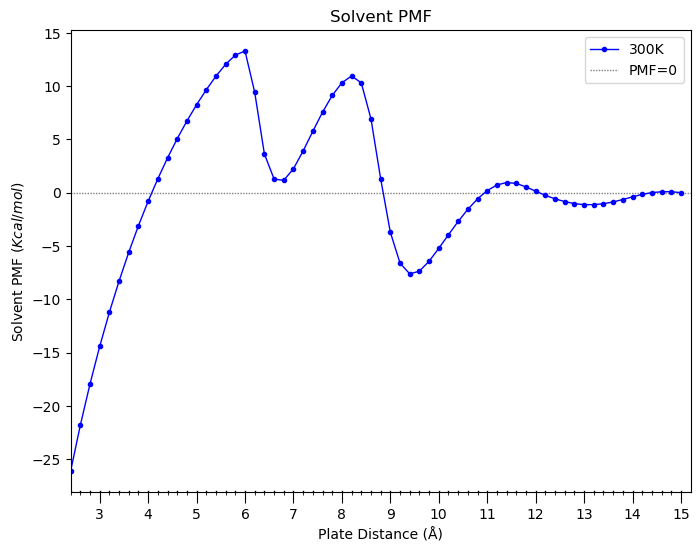

In [44]:
# solvent_pmf_df_300K_file = '/Users/arghavan/lab/hp-results/pmf/solvent_pmf_300K.csv'
# solvent_pmf_df_300K = pd.read_csv(solvent_pmf_df_300K_file, sep='\t', index_col=None, header=0)

plt.figure(figsize=(8, 6))
plt.plot(solvent_pmf_df_300K['Distance(Å)'], solvent_pmf_df_300K['Solvent_PMF_300K'], 'bo-', markersize=3, linewidth=1, label='300K', zorder=2)
plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, label='PMF=0', zorder=1)


plt.title('Solvent PMF')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Solvent PMF $(Kcal/mol)$')
plt.xlim(2.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(2.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

# plt.savefig(f'{plots_path}/solventPMF_300K.png', dpi=800)
plt.savefig(f'{plots_path}/solventPMF_300K_8_6.png', dpi=800)

# Solvent PMF (above 6.2Å)

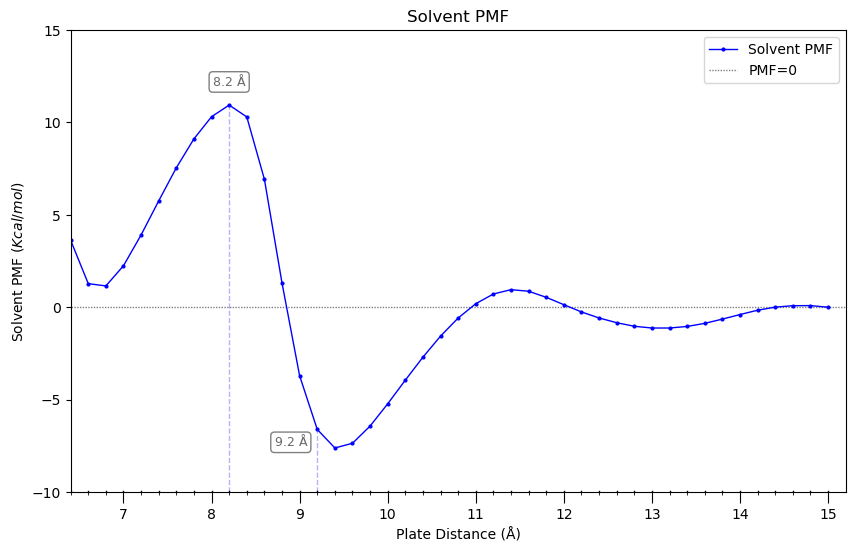

In [14]:
plt.figure(figsize=(10, 6))
# plt.plot(solvent_pmf_df_above_6A_300K['Distance(Å)'], solvent_pmf_df_above_6A_300K['Solvent_PMF_300K'], 'bo-', markersize=2, linewidth=1, label='Solvent PMF', zorder=2)

plt.plot(
    solvent_pmf_df_above_6A_300K['Distance(Å)'].iloc[:],
    solvent_pmf_df_above_6A_300K['Solvent_PMF_300K'].iloc[:],
    'bo-', markersize=2, linewidth=1, label='Solvent PMF')

plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, label='PMF=0', zorder=1)

y_82 = solvent_pmf_df_above_6A_300K.loc[solvent_pmf_df_above_6A_300K['Distance(Å)'] == 8.2,'Solvent_PMF_300K'].values[0]

plt.vlines(x=8.2, ymin=-10, ymax=y_82, color='blue', linestyle='--', linewidth=1,alpha=0.3)
plt.text(x=8.2, y=12, s="8.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


y_92 = solvent_pmf_df_above_6A_300K.loc[ solvent_pmf_df_above_6A_300K['Distance(Å)'] == 9.2, 'Solvent_PMF_300K'].values[0]
plt.vlines(x=9.2, ymin=-10, ymax=y_92, color='blue', linestyle='--', linewidth=1,alpha=0.3)
plt.text(x=8.9, y=-7.5, s="9.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


plt.title('Solvent PMF')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Solvent PMF $(Kcal/mol)$')
plt.ylim(-10.0, 15.0)
plt.xlim(6.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(6.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/solventPMF_300K_above_6.2Å.png', dpi=800)

# Vant Hoff Entropy

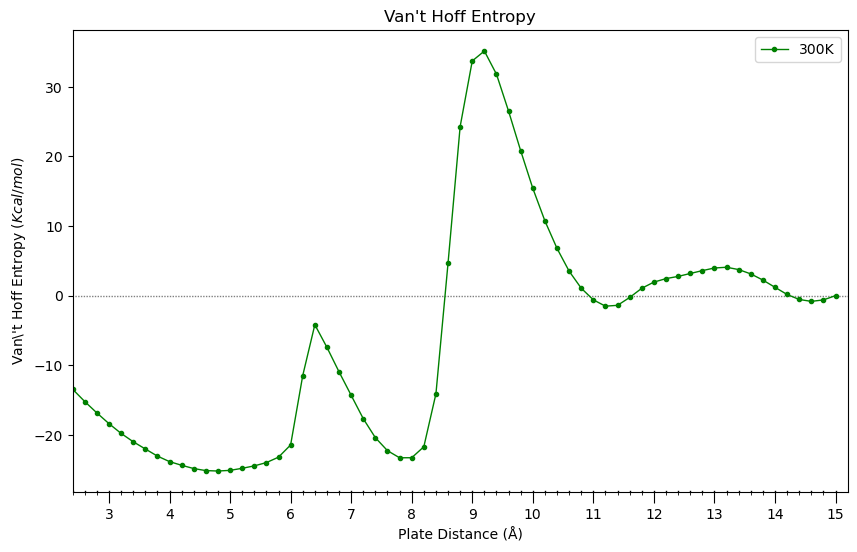

In [163]:
# vanthoff_df_300K_file = '/Users/arghavan/lab/hp-results/pmf/vanthoff_300K.csv'
# vanthoff_df_300K = pd.read_csv(vanthoff_df_300K_file, sep='\t', index_col=None, header=0)

plt.figure(figsize=(10, 6))
plt.plot(vanthoff_df_300K['Distance(Å)'], vanthoff_df_300K['Vant_Hoff_300K_Kcal/mol'], 'go-', markersize=3, linewidth=1, label='300K', zorder=2)
plt.hlines(y=0.00, xmin=2.2, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, zorder=1)


plt.title("Van't Hoff Entropy")
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Van\'t Hoff Entropy $(Kcal/mol)$')
plt.xlim(2.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(2.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/vanthoff_300K.png', dpi=800)

# Vant Hoff Entropy (Above 6Å)

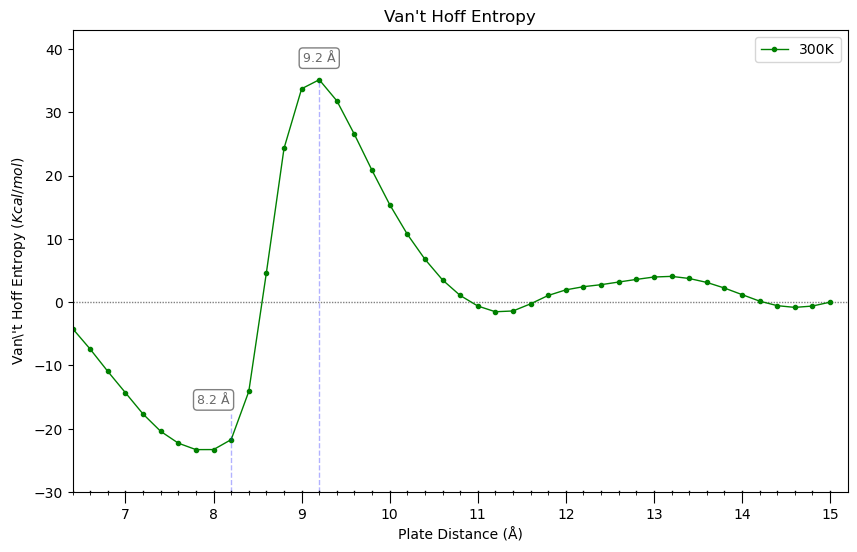

In [164]:
# vanthoff_df_300K_above_6A_file = '/Users/arghavan/lab/hp-results/pmf/vanthoff_300K_above_6A.csv'
# vanthoff_df_300K_above_6A = pd.read_csv(vanthoff_df_300K_above_6A_file, sep='\t', index_col=None, header=0)

plt.figure(figsize=(10, 6))
plt.plot(vanthoff_df_300K_above_6A['Distance(Å)'], vanthoff_df_300K_above_6A['Vant_Hoff_300K_Kcal/mol'], 'go-', markersize=3, linewidth=1, label='300K', zorder=2)
plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, zorder=1)


y_82 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 8.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=8.2, ymin=-30, ymax=y_82+4, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=8.0, y=-16, s="8.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

y_92 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 9.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=9.2, ymin=-30, ymax=y_92, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=9.2, y=38, s="9.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


plt.title("Van't Hoff Entropy")
# plt.title(r"Van't Hoff Entropy ($S = \frac{\partial A}{\partial T}$)")
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Van\'t Hoff Entropy $(Kcal/mol)$')
plt.ylim(-30.0, 43.0)
plt.xlim(6.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(6.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/vanthoff_300K_above_6A.png', dpi=800)

# Contributions

In [116]:
contributions_df

,Distance(Å),Solvent_PMF_300K,Vant_Hoff_300K_Kcal/mol,Energy_300K_Kcal/mol
0,2.4,-26.107835,-13.449974,-12.657861
1,2.6,-21.806237,-15.220203,-6.586034
2,2.8,-17.934000,-16.852934,-1.081066
3,3.0,-14.414622,-18.394938,3.980317
4,3.2,-11.213433,-19.795522,8.582090
...,...,...,...,...
59,14.2,-0.163703,0.163633,-0.327337
60,14.4,0.004737,-0.552350,0.557087
61,14.6,0.081435,-0.827313,0.908747
62,14.8,0.087751,-0.616370,0.704121


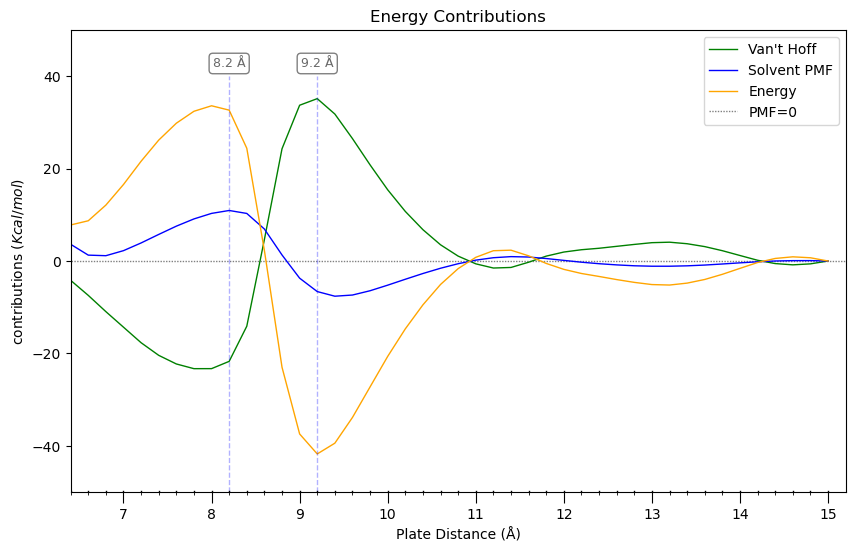

In [165]:
# contributions_df_file = '/Users/arghavan/lab/hp-results/pmf/energy_contributions_300K.csv '
# contributions_df_file = pd.read_csv(vanthoff_df_300K_above_6A_file, sep='\t', index_col=None, header=0)

plt.figure(figsize=(10, 6))
plt.plot(contributions_df['Distance(Å)'], contributions_df['Vant_Hoff_300K_Kcal/mol'], 'g-', markersize=3, linewidth=1, label="Van't Hoff", zorder=2)
plt.plot(contributions_df['Distance(Å)'], contributions_df['Solvent_PMF_300K'], 'b-', markersize=3, linewidth=1, label='Solvent PMF', zorder=2)
plt.plot(contributions_df['Distance(Å)'], contributions_df['Energy_300K_Kcal/mol'], color = 'orange', linestyle='-', markersize=3, linewidth=1, label='Energy', zorder=2)


plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, label='PMF=0', zorder=1)


# y_82 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 8.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=8.2, ymin=-50, ymax=40, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=8.2, y=42, s="8.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# y_92 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 9.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=9.2, ymin=-50, ymax=40, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=9.2, y=42, s="9.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


plt.title("Energy Contributions")
# plt.title(r"Van't Hoff Entropy ($S = \frac{\partial A}{\partial T}$)")
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'contributions $(Kcal/mol)$')
plt.ylim(-50.0, 50.0)
# plt.yticks(np.arange(-50, 51, 10))



plt.xlim(6.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(6.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/energy_contributions.png', dpi=800)

# Energy Plots

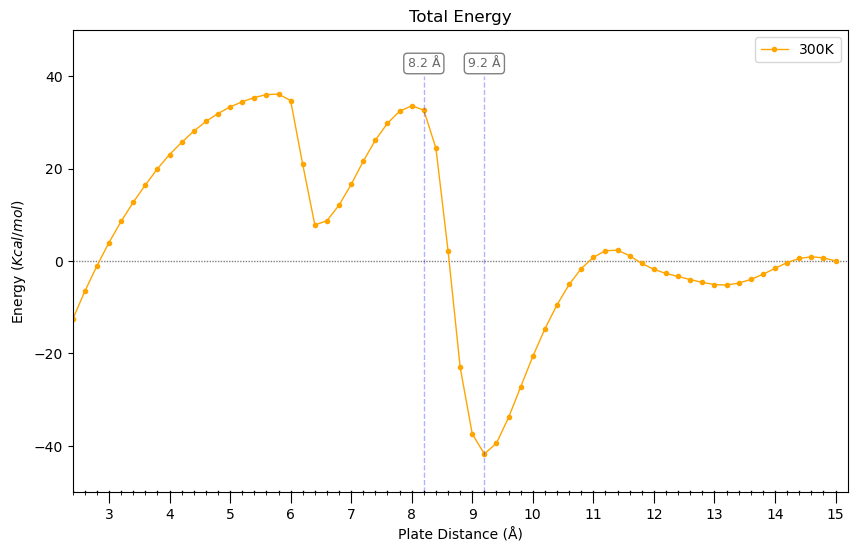

In [166]:
# contributions_df_file = '/Users/arghavan/lab/hp-results/pmf/energy_contributions_300K.csv '
# contributions_df_file = pd.read_csv(vanthoff_df_300K_above_6A_file, sep='\t', index_col=None, header=0)

plt.figure(figsize=(10, 6))
plt.plot(contributions_df['Distance(Å)'], contributions_df['Energy_300K_Kcal/mol'], color = 'orange', marker = 'o', linestyle='-', markersize=3, linewidth=1, label='300K', zorder=2)


plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, zorder=1)


# y_82 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 8.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=8.2, ymin=-50, ymax=40, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=8.2, y=42, s="8.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# y_92 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 9.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=9.2, ymin=-50, ymax=40, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=9.2, y=42, s="9.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


plt.title("Total Energy")
# plt.title(r"Van't Hoff Entropy ($S = \frac{\partial A}{\partial T}$)")
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Energy $(Kcal/mol)$')
plt.ylim(-50.0, 50.0)
# plt.yticks(np.arange(-50, 51, 10))



plt.xlim(2.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(2.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/energy_300K.png', dpi=800)

# Energy Above 6A

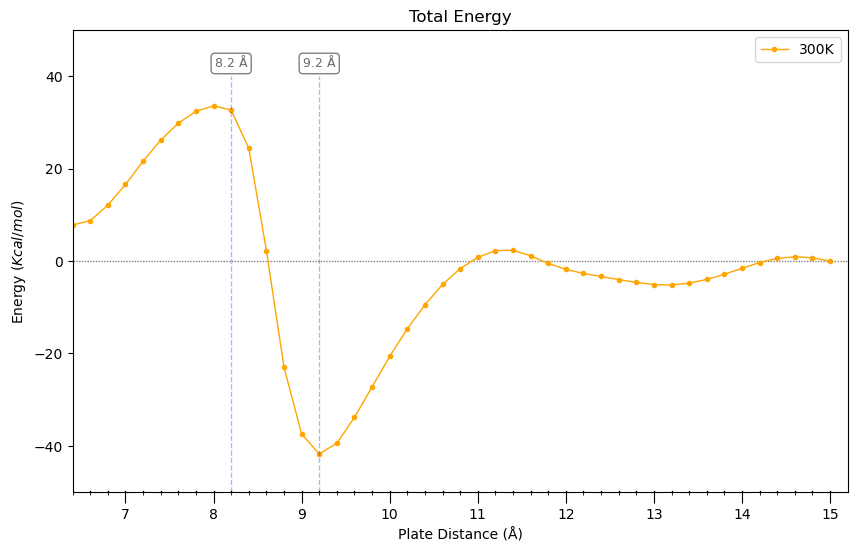

In [167]:
# contributions_df_file = '/Users/arghavan/lab/hp-results/pmf/energy_contributions_300K.csv '
# contributions_df_file = pd.read_csv(vanthoff_df_300K_above_6A_file, sep='\t', index_col=None, header=0)

plt.figure(figsize=(10, 6))
plt.plot(contributions_df['Distance(Å)'], contributions_df['Energy_300K_Kcal/mol'], color = 'orange', marker = 'o', linestyle='-', markersize=3, linewidth=1, label='300K', zorder=2)


plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, zorder=1)


# y_82 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 8.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=8.2, ymin=-50, ymax=40, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=8.2, y=42, s="8.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# y_92 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 9.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=9.2, ymin=-50, ymax=40, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=9.2, y=42, s="9.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


plt.title("Total Energy")
# plt.title(r"Van't Hoff Entropy ($S = \frac{\partial A}{\partial T}$)")
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Energy $(Kcal/mol)$')
plt.ylim(-50.0, 50.0)
# plt.yticks(np.arange(-50, 51, 10))



plt.xlim(6.4,15.2)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(6.4,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/energy_300K_above_6Å.png', dpi=800)

# Leonnard Jones

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os


input_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan/PMF-TdS-data/Energy-data.txt'
all_data_df = pd.read_csv(input_file, sep='\s+', index_col=0, header=0)

distance_A = round(all_data_df['distance']*10, 2)
all_data_df.columns


Index(['distance', 'pmf280', 'pmf300', 'pmf320', 'pmf360', 'pmf280_divkT',
       'pmf300_divkT', 'pmf320_divkT', 'pmf360_divkT', 'LJ', 'LJ_divkT280',
       'LJ_divkT300', 'LJ_divkT320', 'LJ_divkT360', 'gist260e', 'gist280e',
       'gist300e', 'gist320e', 'gist360e', 'gist260s', 'gist280s', 'gist300s',
       'gist320s', 'gist360s', 'gmx260e', 'gmx280e', 'gmx300e', 'gmx320e',
       'gmx360e', 'gmx260e_err', 'gmx280e_err', 'gmx300e_err', 'gmx320e_err',
       'gmx360e_err'],
      dtype='object')

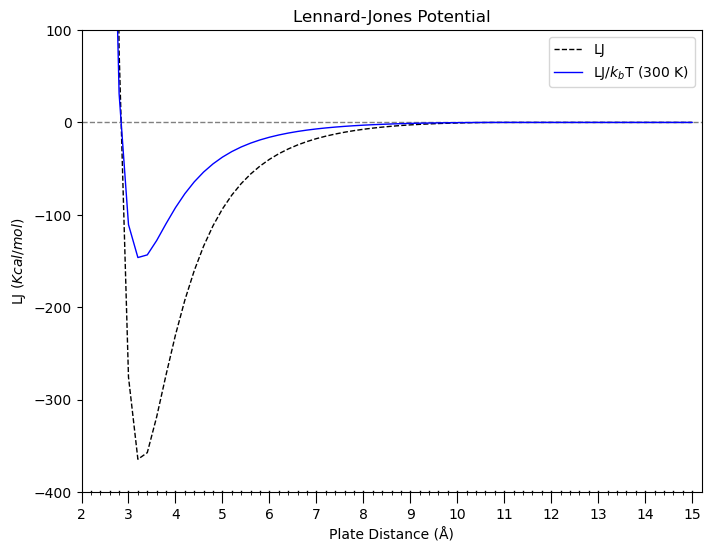

In [42]:
plt.figure(figsize=(8, 6))
plt.plot(distance_A, all_data_df['LJ'], color='black', linestyle='--', markersize=3, linewidth=1, label='LJ', zorder=2)
plt.plot(distance_A, all_data_df['LJ_divkT300'], 'b-', markersize=3, linewidth=1, label=r'LJ/$k_b$T (300 K)', zorder=2)
plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle='--', linewidth=1, zorder=1)


plt.title('Lennard-Jones Potential')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'LJ $(Kcal/mol)$')
plt.xlim(2.0,15.2)
plt.ylim (-400.0, 100.0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(2.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

# plt.savefig(f'{plots_path}/LJ_potential.png', dpi=800)
plt.savefig(f'{plots_path}/LJ_potential_8_6.png', dpi=800)


# Leonnard Jones Above 6 Å

In [56]:
# Truncate data below 6 Å

LJ_df = pd.DataFrame({
    'Distance(Å)': solvent_pmf_df_300K['Distance(Å)'].iloc[1:].values,
    'LJ_kcal/mol': all_data_df['LJ'].values})

LJ_df.to_csv(f'{output_path}LJ_df.csv',sep='\t', index=False)


# Truncate data below 6 Å
LJ_df_above_6A = LJ_df.iloc[18:].copy()
LJ_df_above_6A.reset_index(drop=True, inplace=True)
LJ_df_above_6A
LJ_df_above_6A.to_csv(f'{output_path}LJ_df_above_6A.csv',sep='\t', index=False)

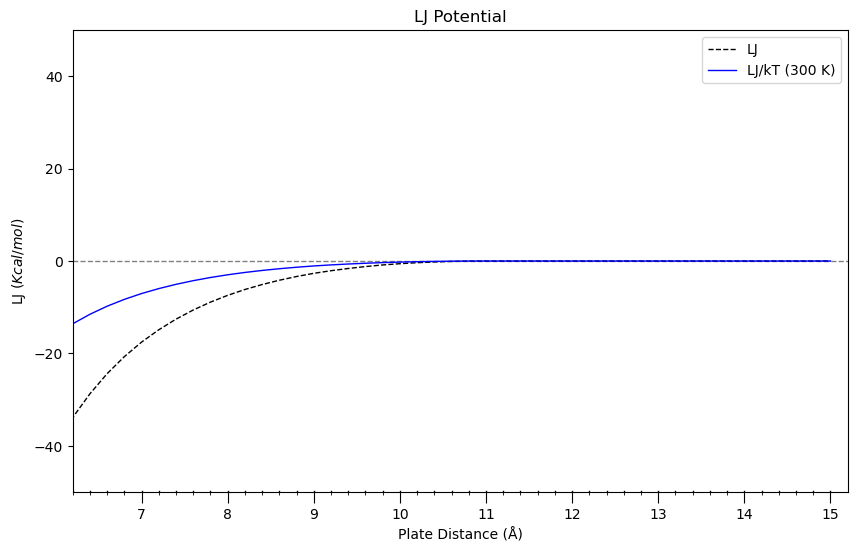

In [91]:
plt.figure(figsize=(10, 6))
plt.plot(distance_A, all_data_df['LJ'], color='black', linestyle='--', markersize=3, linewidth=1, label='LJ', zorder=2)
plt.plot(distance_A, all_data_df['LJ_divkT300'], 'b-', markersize=3, linewidth=1, label='LJ/kT (300 K)', zorder=2)
plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle='--', linewidth=1, zorder=1)


plt.title('LJ Potential')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'LJ $(Kcal/mol)$')
plt.xlim(6.2,15.2)
plt.ylim (-50.0, 50.0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

# plt.savefig(f'{plots_path}/LJ_potential_above_6A.png', dpi=800)


# Total PMF

In [46]:
output_path

'/Users/arghavan/lab/hp-results/pmf/'

In [17]:
all_pmf_df = pd.DataFrame({
    'Distance(Å)': solvent_pmf_df_300K['Distance(Å)'].iloc[1:].values,
    'LJ': all_data_df['LJ'].values,
    'Solvent_PMF': solvent_pmf_df_300K['Solvent_PMF_300K'].iloc[1:].values
})

all_pmf_df['Total_PMF'] = all_pmf_df['LJ'] + all_pmf_df['Solvent_PMF']

all_pmf_df.to_csv(f'{output_path}/all_pmf_data_300K.csv',
                   sep='\t', index=False, header=True, float_format="%.7f")
# all_pmf_df

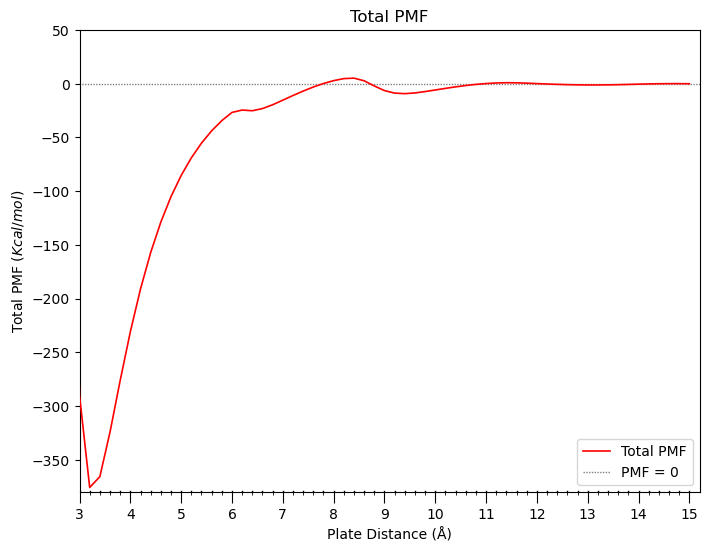

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(all_pmf_df['Distance(Å)'], all_pmf_df['Total_PMF'], color='red', linestyle='-', markersize=1, linewidth=1.2, label='Total PMF', zorder=3 )
# plt.plot(all_pmf_df['Distance(Å)'], all_pmf_df['Solvent_PMF'], color='blue', marker='o', linestyle='-', markersize=1, linewidth=1, label='Solvent PMF (300 K)', zorder=2)
# plt.plot(all_pmf_df['Distance(Å)'], all_pmf_df['LJ'], color='black', linestyle='--', markersize=3, linewidth=0.7, label='LJ Potential', zorder=2)
plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, label = 'PMF = 0', zorder=1)
# plt.vlines(x=6.0, ymin=-380, ymax=45, color='blue', linestyle='--', linewidth=1, alpha=0.3)

plt.title('Total PMF')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Total PMF $(Kcal/mol)$')
plt.xlim(3.0,15.2)
plt.ylim (-380.0, 50.0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(3.0,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend(loc='lower right')
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

# plt.savefig(f'{plots_path}/total_pmf_only_8_6.png', dpi=800)

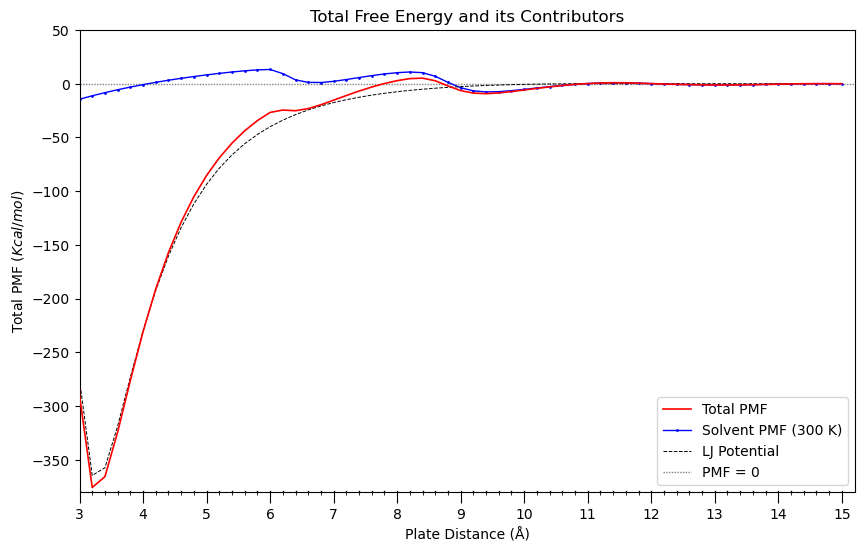

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(all_pmf_df['Distance(Å)'], all_pmf_df['Total_PMF'], color='red', linestyle='-', markersize=1, linewidth=1.2, label='Total PMF', zorder=3 )
plt.plot(all_pmf_df['Distance(Å)'], all_pmf_df['Solvent_PMF'], color='blue', marker='o', linestyle='-', markersize=1, linewidth=1, label='Solvent PMF (300 K)', zorder=2)
plt.plot(all_pmf_df['Distance(Å)'], all_pmf_df['LJ'], color='black', linestyle='--', markersize=3, linewidth=0.7, label='LJ Potential', zorder=2)
plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, label = 'PMF = 0', zorder=1)


plt.title('Total Free Energy and its Contributors')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Total PMF $(Kcal/mol)$')
plt.xlim(3.0,15.2)
plt.ylim (-380.0, 50.0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(3.0,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/total_pmf_kamel.png', dpi=800)

# Total PMF above 6 A

In [ ]:


all_pmf_above_6A = all_pmf_df.iloc[18:].copy()
all_pmf_above_6A.reset_index(drop=True, inplace=True)
all_pmf_above_6A
all_pmf_above_6A.to_csv(f'{output_path}all_pmf_300K_above_6A.csv',sep='\t', index=False)

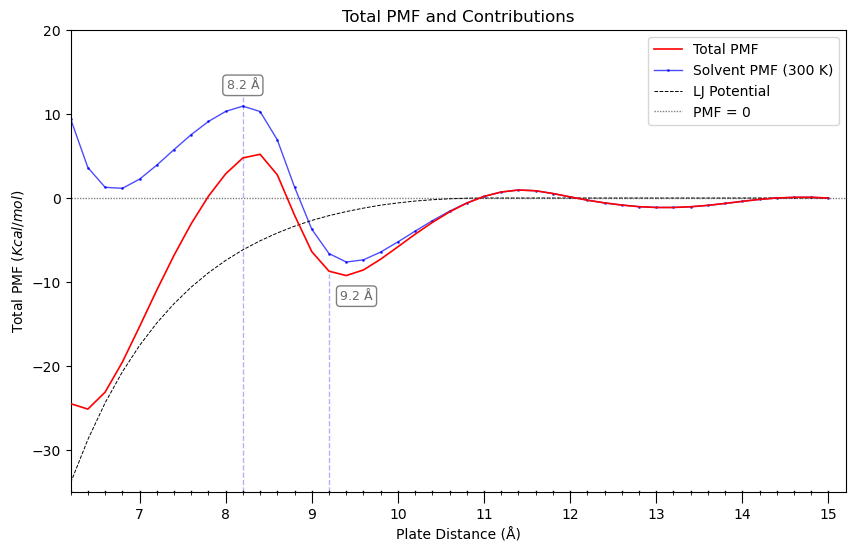

In [187]:
plt.figure(figsize=(10, 6))
plt.plot(all_pmf_above_6A['Distance(Å)'], all_pmf_above_6A['Total_PMF'], color='red', linestyle='-', markersize=1, linewidth=1.2, label='Total PMF', zorder=3 )
plt.plot(all_pmf_above_6A['Distance(Å)'], all_pmf_above_6A['Solvent_PMF'], color='blue', marker='o', linestyle='-', markersize=1, linewidth=1, label='Solvent PMF (300 K)', zorder=2, alpha=0.7)
plt.plot(all_pmf_above_6A['Distance(Å)'], all_pmf_above_6A['LJ'], color='black', linestyle='--', markersize=3, linewidth=0.7, label='LJ Potential', zorder=2)
plt.hlines(y=0.00, xmin=2.0, xmax=15.2, color='grey', linestyle=(0, (1, 1)), linewidth=1, label = 'PMF = 0', zorder=1)

plt.vlines(x=8.2, ymin=-35, ymax=12, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=8.2, y=13, s="8.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# y_92 = vanthoff_df_300K_above_6A.loc[vanthoff_df_300K_above_6A['Distance(Å)'] == 9.2,'Vant_Hoff_300K_Kcal/mol'].values[0]
plt.vlines(x=9.2, ymin=-35, ymax=-9, color='blue', linestyle='--', linewidth=1, alpha=0.3)
plt.text(x=9.52, y=-12.1, s="9.2 Å", ha='center', fontsize=9, color='dimgrey',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

plt.title('Total PMF and Contributions')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Total PMF $(Kcal/mol)$')
plt.xlim(6.2,15.2)
plt.ylim (-35.0, 20.0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
plots_path = f'{output_path}/plots/'
os.makedirs(plots_path, exist_ok=True)

plt.savefig(f'{plots_path}/total_pmf_above_6A.png', dpi=800)

# PMF/KbT

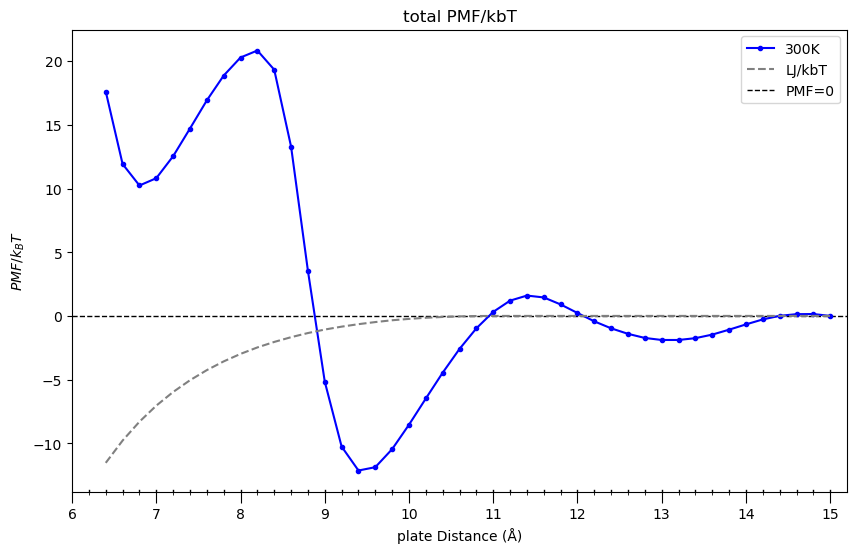

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['distance'], df['pmf300_divkT'], 'bo-', markersize=3, label='300K', zorder=2)
plt.plot(df['distance'], df['LJ_divkT300'], color='grey', linestyle='--', markersize=3, label='LJ/kbT', zorder=2)
plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='black', linestyle='--', linewidth=1, label='PMF=0', zorder=1)


plt.title('total PMF/kbT')
plt.xlabel('plate Distance (Å)')
plt.ylabel(r'$PMF/k_B T$')
# plt.ylim(-0.1, 3.5)
plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
# plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# small_ticks = np.arange(6.2,15.2, 0.1)
# plt.gca().set_xticks(small_ticks, minor=True)

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()

# plt.savefig(f'{output_path}/totalPMF.png', dpi=600)


# GIST Energies

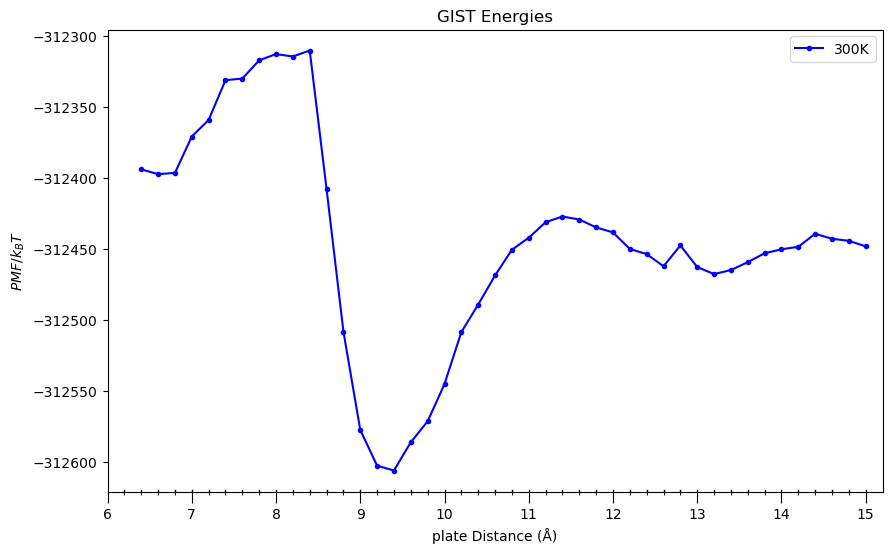

In [38]:
plt.figure(figsize=(10, 6))
gist_energies = df['gist300e']
plt.plot(df['distance'], gist_energies, 'bo-', markersize=3, label='300K', zorder=2)
# plt.plot(df['distance'], df['LJ_divkT300'], color='grey', linestyle='--', markersize=3, label='LJ/kbT', zorder=2)
# plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='black', linestyle='--', linewidth=1, label='PMF=0', zorder=1)


plt.title('GIST Energies')
plt.xlabel('plate Distance (Å)')
plt.ylabel(r'$PMF/k_B T$')
# plt.ylim(-0.1, 3.5)
plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
# plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# small_ticks = np.arange(6.2,15.2, 0.1)
# plt.gca().set_xticks(small_ticks, minor=True)

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()
# plt.savefig(f'{output_path}/totalPMF.png', dpi=600)

# PMF correct data

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

input_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/pmf_kcal.txt'
cols = ['distance', '260', '280', '300','320','360']
df_in_nm = pd.read_csv(input_file, delim_whitespace=True, names=cols)
output_path = '/Users/arghavan/lab/hp-results/total-energy-plots/'

/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_18515/2998384588.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_in_nm = pd.read_csv(input_file, delim_whitespace=True, names=cols)


In [64]:
df = df_in_nm.iloc[20:].copy()
df.reset_index(drop=True, inplace=True)

print (df.columns)
df['distance']

Index(['distance', '260', '280', '300', '320', '360'], dtype='object')


0      6.4
1      6.6
2      6.8
3      7.0
4      7.2
5      7.4
6      7.6
7      7.8
8      8.0
9      8.2
10     8.4
11     8.6
12     8.8
13     9.0
14     9.2
15     9.4
16     9.6
17     9.8
18    10.0
19    10.2
20    10.4
21    10.6
22    10.8
23    11.0
24    11.2
25    11.4
26    11.6
27    11.8
28    12.0
29    12.2
30    12.4
31    12.6
32    12.8
33    13.0
34    13.2
35    13.4
36    13.6
37    13.8
38    14.0
39    14.2
40    14.4
41    14.6
42    14.8
43    15.0
Name: distance, dtype: float64

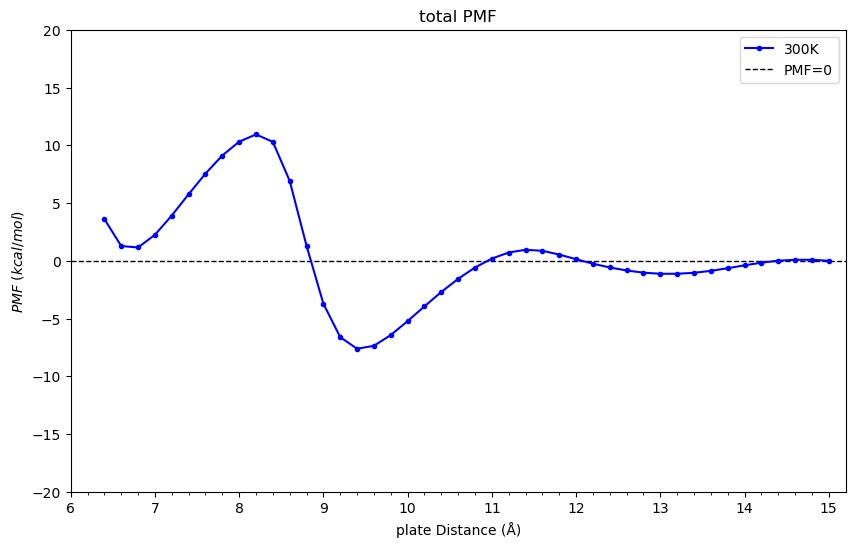

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['distance'], df['300'], 'bo-', markersize=3, label='300K', zorder=2)
# plt.plot(df['distance'], df['LJ'], color='grey', linestyle='--', markersize=3, label='LJ', zorder=2)
plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='black', linestyle='--', linewidth=1, label='PMF=0', zorder=1)


plt.title('total PMF')
plt.xlabel('plate Distance (Å)')
plt.ylabel(r'$PMF \ (kcal/mol)$')
plt.ylim(-20, 20)
plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# # small_ticks = np.arange(6.2,15.2, 0.1)
# # plt.gca().set_xticks(small_ticks, minor=True)

# plt.tick_params(axis='x', which='major', length=8)   
# plt.tick_params(axis='x', which='minor', length=2)   
# for t in medium_ticks:
#     plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()

# plt.savefig(f'{output_path}/totalPMF.png', dpi=600)


# GIST Energy

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

input_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/gist_PE.txt'
cols = ['distance', '260', '280', '300','320','360']
df_in_nm = pd.read_csv(input_file, delim_whitespace=True, names=cols)
output_path = '/Users/arghavan/lab/hp-results/total-energy-plots/'

/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_18515/3980538641.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_in_nm = pd.read_csv(input_file, delim_whitespace=True, names=cols)


In [ ]:
df = df_in_nm.iloc[20:].copy()
df.reset_index(drop=True, inplace=True)

print (df.columns)
df['distance']

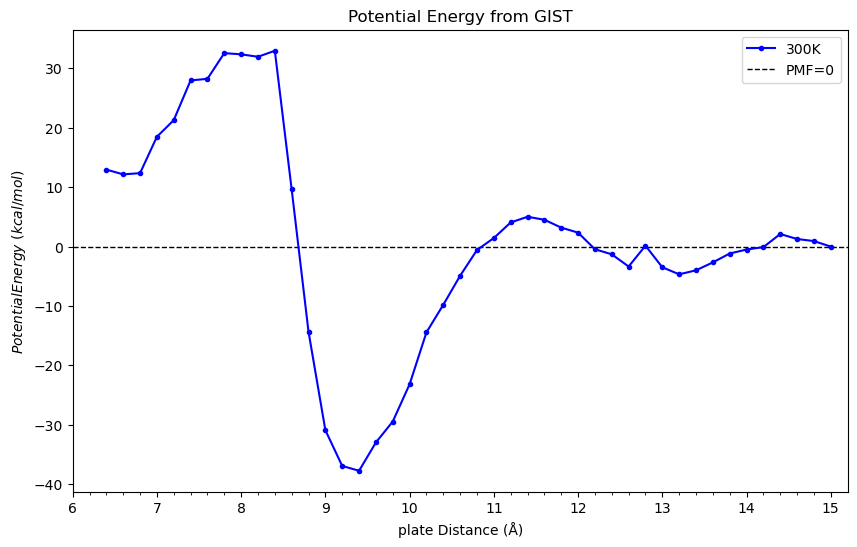

In [69]:
plt.figure(figsize=(10, 6))
plt.plot(df['distance'], df['300'], 'bo-', markersize=3, label='300K', zorder=2)
# plt.plot(df['distance'], df['LJ'], color='grey', linestyle='--', markersize=3, label='LJ', zorder=2)
plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='black', linestyle='--', linewidth=1, label='PMF=0', zorder=1)


plt.title('Potential Energy from GIST')
plt.xlabel('plate Distance (Å)')
plt.ylabel(r'$Potential Energy \ (kcal/mol)$')
# plt.ylim(-20, 20)
plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# # small_ticks = np.arange(6.2,15.2, 0.1)
# # plt.gca().set_xticks(small_ticks, minor=True)

# plt.tick_params(axis='x', which='major', length=8)   
# plt.tick_params(axis='x', which='minor', length=2)   
# for t in medium_ticks:
#     plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()

# plt.savefig(f'{output_path}/totalPMF.png', dpi=600)


# GIST entropy

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

input_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/gist_negTdS.txt'
cols = ['distance', '260', '280', '300','320','360']
df_in_nm = pd.read_csv(input_file, delim_whitespace=True, names=cols)
output_path = '/Users/arghavan/lab/hp-results/total-energy-plots/'
df = df_in_nm.iloc[20:].copy()
df.reset_index(drop=True, inplace=True)


/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_18515/3141340608.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_in_nm = pd.read_csv(input_file, delim_whitespace=True, names=cols)


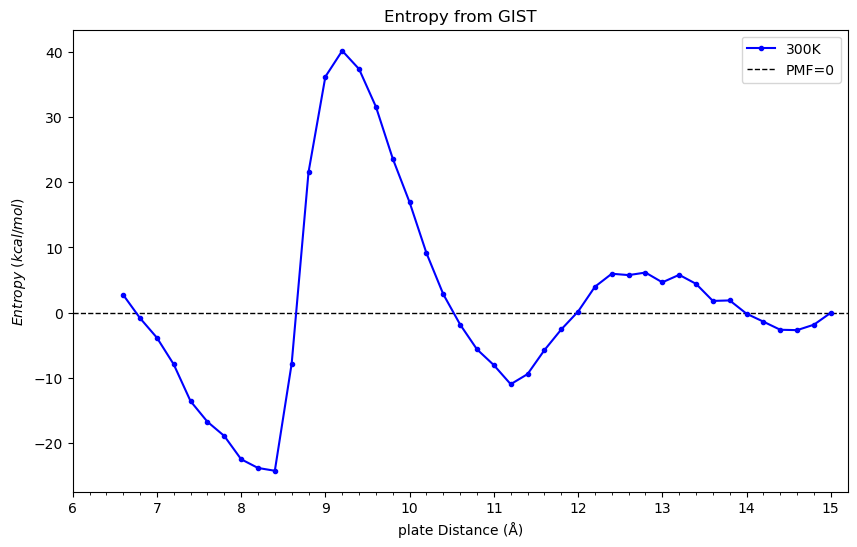

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(df['distance'], df['300'], 'bo-', markersize=3, label='300K', zorder=2)
# plt.plot(df['distance'], df['LJ'], color='grey', linestyle='--', markersize=3, label='LJ', zorder=2)
plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='black', linestyle='--', linewidth=1, label='PMF=0', zorder=1)


plt.title('Entropy from GIST')
plt.xlabel('plate Distance (Å)')
plt.ylabel(r'$Entropy \ (kcal/mol)$')
# plt.ylim(-20, 20)
plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# # small_ticks = np.arange(6.2,15.2, 0.1)
# # plt.gca().set_xticks(small_ticks, minor=True)

# plt.tick_params(axis='x', which='major', length=8)   
# plt.tick_params(axis='x', which='minor', length=2)   
# for t in medium_ticks:
#     plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()

# plt.savefig(f'{output_path}/totalPMF.png', dpi=600)


# Contributions

/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_17794/2233636016.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  energy_df = pd.read_csv(energy_file, delim_whitespace=True, names=cols)
/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_17794/2233636016.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  entropy_df = pd.read_csv(entropy_file, delim_whitespace=True, names=cols)
/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_17794/2233636016.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pmf_df = pd.read_csv(pmf_file, delim_whitespace=True, names=cols)
/var/folders/gy/kd2rvc8557g97z7xqgk_lrt80000gn/T/ipykernel_17794/2233636016.py:32: FutureWarning: The 'deli

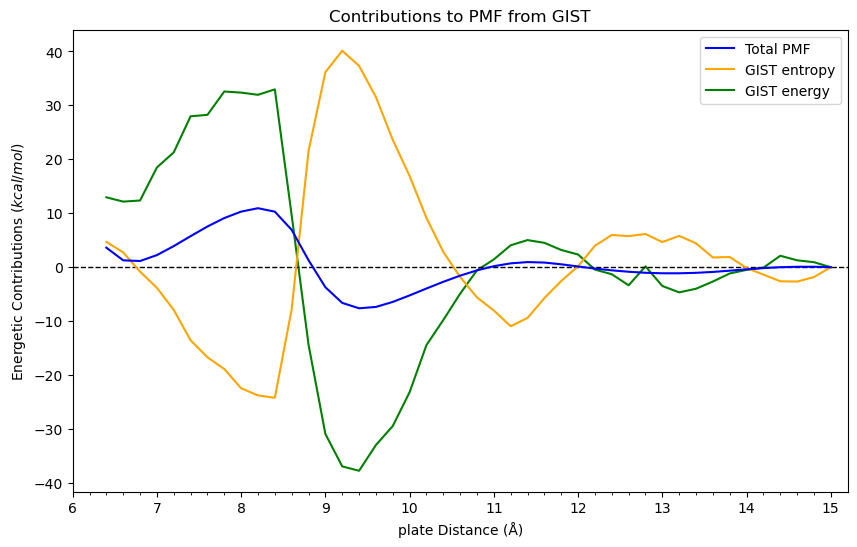

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

cols = ['distance', '260', '280', '300','320','360']
output_path = '/Users/arghavan/lab/hp-results/total-energy-plots/'

# --------- Energy Contribution ---------
energy_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/gist_PE.txt'
energy_df = pd.read_csv(energy_file, delim_whitespace=True, names=cols)
energy_df = energy_df.iloc[20:].copy()
energy_df.reset_index(drop=True, inplace=True)


# --------- Entropy Contribution ---------
entropy_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/gist_negTdS.txt'
entropy_df = pd.read_csv(entropy_file, delim_whitespace=True, names=cols)
entropy_df = entropy_df.iloc[19:].copy()
entropy_df.reset_index(drop=True, inplace=True)


# --------- PMF Contribution ---------
pmf_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/pmf_kcal.txt'
pmf_df = pd.read_csv(pmf_file, delim_whitespace=True, names=cols)
pmf_df = pmf_df.iloc[20:].copy()
pmf_df.reset_index(drop=True, inplace=True)

# --------- PMF/kbT Contribution ---------
pmf_file = '/Users/arghavan/Graduate Center Dropbox/Arghavan Vedadi Gargari/Hydrophobic Plates/Arghavan//PMF-TdS-data/PMF-tdS data/pmf_kt.txt'
pmf_kt_df = pd.read_csv(pmf_file, delim_whitespace=True, names=cols)
pmf_kt_df = pmf_kt_df.iloc[20:].copy()
pmf_kt_df.reset_index(drop=True, inplace=True)


# --------- LJ solvent PMF Contribution ---------
LJ_file = '/Users/arghavan/lab/hp-results-pc/wall-LJ-energy/300K-wall_LJ_energies.dx'
LJ_cols = ['distance', 'LJ']
LJ_df = pd.read_csv(LJ_file, delim_whitespace=True, names=LJ_cols, skiprows=2)

# print (LJ_df.columns)
# LJ_df['distance']

# LJ_df
# plt.plot(LJ_df['distance'], LJ_df['LJ'], 'bo-', markersize=3, label='300K', zorder=2)
# --------- Plotting ---------

plt.figure(figsize=(10, 6))
plt.plot(pmf_df['distance'], pmf_df['300'], 'b-', markersize=3, label='Total PMF', zorder=3)
# plt.plot(pmf_df['distance'], pmf_kt_df['300'], color='grey', markersize=3, label='Total PMF/kbT', zorder=3)
plt.plot(pmf_df['distance'], entropy_df['300'], color='orange', markersize=3, label='GIST entropy', zorder=2)
plt.plot(pmf_df['distance'], energy_df['300'], color='green', markersize=3, label='GIST energy', zorder=1)
# plt.plot(pmf_df['distance'], energy_df['300'], color='red', markersize=3, label='E+S', zorder=1)
# plt.plot(df['distance'], df['LJ'], color='grey', linestyle='--', markersize=3, label='LJ', zorder=2)
plt.hlines(y=0.00, xmin=6.0, xmax=15.2, color='black', linestyle='--', linewidth=1, zorder=1)
solvent_pmf = pmf_df['300'] - LJ_df['LJ']

# plt.plot(pmf_df['distance'], solvent_pmf, 'grey', markersize=3, label='300K solvent PMF', zorder=2)



plt.title('Contributions to PMF from GIST')
plt.xlabel('plate Distance (Å)')
plt.ylabel(r'Energetic Contributions $(kcal/mol)$')
# plt.ylim(-40, 40)
plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# # small_ticks = np.arange(6.2,15.2, 0.1)
# # plt.gca().set_xticks(small_ticks, minor=True)

# plt.tick_params(axis='x', which='major', length=8)   
# plt.tick_params(axis='x', which='minor', length=2)   
# for t in medium_ticks:
#     plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


plt.legend()

plt.savefig(f'{output_path}/energy-contributions.png', dpi=600)




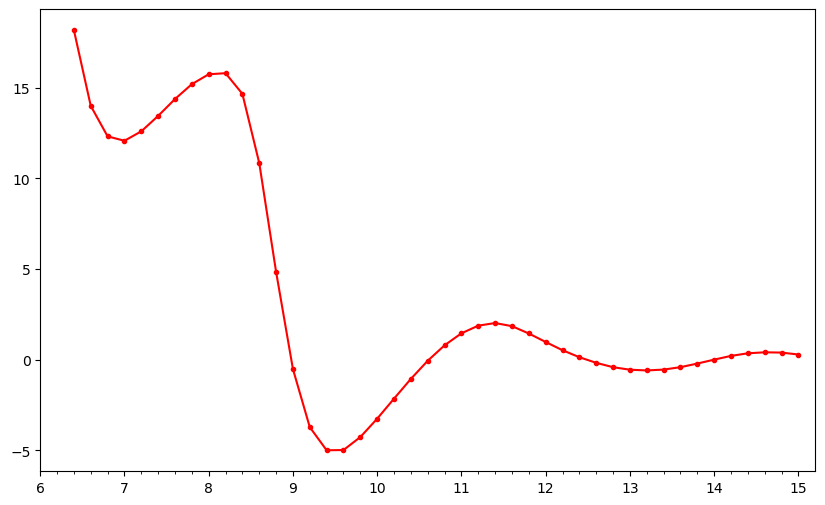

In [14]:
LJ_file = '/Users/arghavan/lab/hp-results-pc/wall-LJ-energy/300K-wall_LJ_energies.dx'
cols = ['distance', 'LJ']
LJ_df = pd.read_csv(LJ_file, delimiter=',', names=cols, skiprows=2)

# print (LJ_df.columns)
# LJ_df['distance']

plt.figure(figsize=(10, 6))

solvent_pmf = pmf_df['300'] - LJ_df['LJ']


# LJ_df
# plt.plot(LJ_df['distance'], LJ_df['LJ'], 'bo-', markersize=3, label='300K', zorder=2)

plt.xlim(6.0,15.2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

plt.plot(LJ_df['distance'], solvent_pmf, 'ro-', markersize=3, label='300K solvent PMF', zorder=2)


In [13]:
LJ_df

,distance,LJ
0,6.4,-14.550829
1,6.6,-12.726465
2,6.8,-11.169118
3,7.0,-9.834414
4,7.2,-8.686198
5,7.4,-7.694763
6,7.6,-6.835705
7,7.8,-6.088872
8,8.0,-5.437515
9,8.2,-4.867682
